In [1]:
%config InlineBackend.figure_formats = ['jpeg']

import sys
sys.path.insert(0, "../src")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import SimpleITK as sitk
from tqdm.auto import tqdm

from generate_cases import *
from seg_metrics import compute_segmentation_metrics

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.figsize": (6.5, 4.5),   # letter-paper single column width
    "figure.dpi": 72,
    "axes.prop_cycle": plt.cycler(color=["black", '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']),
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:



# Collect all the data metadata
csv_path = Path("../data/raw/zenodo/picai/record-6624726/images_nii.csv")
picai_cases = pd.read_csv(csv_path)
# Convert all path to absolute paths
for col in picai_cases.columns[2:]:
    picai_cases[col] = picai_cases[col].apply(lambda x: str((csv_path.parent / x).resolve()))
# Concatenate locally run predictions

# The files are in paths like: results/picai_pred_monai_prostate/images_nii/10000/10000_1000000_t2w/10000_1000000_t2w_trans.nii.gz
picai_cases["Prostate158_adams22"] = picai_cases["ID"].apply(lambda id: f"../results/picai_pred_monai_prostate/images_nii/{id.split("_")[0]}/{id}_t2w/{id}_t2w_trans.nii.gz")
assert all(Path(p).exists() for p in picai_cases["Prostate158_adams22"]), "Some predictions are missing!"

picai_cases["Prostate158_nnunet"] = picai_cases["ID"].apply(lambda id: f"../results/picai_pred_prostate158_3d_fullres/{id}.nii.gz")
assert all(Path(p).exists() for p in picai_cases["Prostate158_nnunet"]), "Some predictions are missing!"

picai_cases["PROMISE12_nnunet"] = picai_cases["ID"].apply(lambda id: f"../results/picai_pred_promise12_3d_fullres/{id}.nii.gz")
assert all(Path(p).exists() for p in picai_cases["PROMISE12_nnunet"]), "Some predictions are missing!"

picai_cases["pooled_nnunet"] = picai_cases["ID"].apply(lambda id: f"../results/picai_pred_pooled_3d_fullres/{id}.nii.gz")
assert all(Path(p).exists() for p in picai_cases["pooled_nnunet"]), "Some predictions are missing!"

picai_cases

,ID,t2,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet,pooled_nnunet
0,10000_1000000,images_nii/10000/10000_1000000_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/100...,../results/picai_pred_pooled_3d_fullres/10000_...
1,10001_1000001,images_nii/10001/10001_1000001_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/100...,../results/picai_pred_pooled_3d_fullres/10001_...
2,10002_1000002,images_nii/10002/10002_1000002_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/100...,../results/picai_pred_pooled_3d_fullres/10002_...
3,10003_1000003,images_nii/10003/10003_1000003_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/100...,../results/picai_pred_pooled_3d_fullres/10003_...
4,10004_1000004,images_nii/10004/10004_1000004_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/100...,../results/picai_pred_pooled_3d_fullres/10004_...
...,...,...,...,...,...,...,...,...,...,...
1495,11471_1001495,images_nii/11471/11471_1001495_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/114...,../results/picai_pred_pooled_3d_fullres/11471_...
1496,11472_1001496,images_nii/11472/11472_1001496_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/114...,../results/picai_pred_pooled_3d_fullres/11472_...
1497,11473_1001497,images_nii/11473/11473_1001497_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/114...,../results/picai_pred_pooled_3d_fullres/11473_...
1498,11474_1001498,images_nii/11474/11474_1001498_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,

In [3]:
from concurrent.futures import ProcessPoolExecutor
import os

def _row_volumes(row):
    import nibabel as nib
    import numpy as np
    for col, path in row.items():
        if col in ("ID", "t2"):
            continue
        img = nib.load(path)
        data = np.asarray(img.dataobj)
        voxel_vol_mm3 = np.prod(img.header.get_zooms()[:3])
        row[col] = (data > 0).sum() * voxel_vol_mm3 / 1000.0
    return row

rows = picai_cases.to_dict("records")

with ProcessPoolExecutor(os.cpu_count() - 1) as pool:
    results = list(tqdm(pool.map(_row_volumes, rows), total=len(rows)))

volumes = pd.DataFrame(results)


# if "gt" not in volumes.columns:
    # volumes.insert(2, "gt", volumes[['whole_gland_ai_bosma22b', 'whole_gland_ai_guerbet23', 'zonal_pz_tz_ai_heviai23', 'zonal_pz_tz_ai_yuan23']].median(axis=1))
volumes["gt"] = volumes[['whole_gland_ai_bosma22b', 'whole_gland_ai_guerbet23', 'zonal_pz_tz_ai_heviai23', 'zonal_pz_tz_ai_yuan23']].median(axis=1)


volumes


  0%|          | 0/1500 [00:00<?, ?it/s]

,ID,t2,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet,pooled_nnunet,gt
0,10000_1000000,images_nii/10000/10000_1000000_t2w.nii.gz,35.708303,35.502607,35.626338,37.591149,39.163103,33.615845,43.323742,38.731090,35.667320
1,10001_1000001,images_nii/10001/10001_1000001_t2w.nii.gz,89.674461,88.484732,92.784213,93.510945,98.505729,86.998868,95.572557,90.625401,91.229337
2,10002_1000002,images_nii/10002/10002_1000002_t2w.nii.gz,68.688750,70.541250,74.671500,73.729500,73.197744,67.087500,65.831250,72.424500,72.135375
3,10003_1000003,images_nii/10003/10003_1000003_t2w.nii.gz,72.416250,72.231000,74.361000,73.858500,77.959506,69.359250,76.050000,72.078000,73.137375
4,10004_1000004,images_nii/10004/10004_1000004_t2w.nii.gz,60.776244,61.174764,61.069140,64.428048,67.939890,59.685012,64.924092,68.971824,61.121952
...,...,...,...,...,...,...,...,...,...,...,...
1495,11471_1001495,images_nii/11471/11471_1001495_t2w.nii.gz,51.678375,52.892000,51.163000,51.168250,52.404629,46.624375,52.391500,48.435625,51.423313
1496,11472_1001496,images_nii/11472/11472_1001496_t2w.nii.gz,34.839720,35.065224,36.317160,39.699396,70.644306,31.160376,44.482932,41.031036,35.691192
1497,11473_1001497,images_nii/11473/11473_1001497_t2w.nii.gz,71.053200,71.361972,73.283292,74.853072,79.467149,72.360540,80.999676,75.067560,72.322632
1498,11474_1001498,images_nii/11474/11474_1001498_t2w.nii.gz,74.302031,75.453750,78.582656,76.545000,83.408899,73.213594,87.537656,80.564063,75.999375


In [4]:
# from concurrent.futures import ProcessPoolExecutor
# from pathlib import Path
# import os

# def _load_lesion_vol(path):
#     import nibabel as nib
#     import numpy as np
#     img = nib.load(path)
#     vox_vol = np.prod(img.header.get_zooms()[:3]) / 1000
#     vol = float((np.asarray(img.dataobj) > 0).sum() * vox_vol)
#     case_id = Path(path).name.removesuffix(".nii.gz")
#     return case_id, vol

# base = Path("../data/raw/zenodo/picai/picai_labels/csPCa_lesion_delineations/human_expert")
# labels = list((base / "resampled").glob("*.nii.gz"))
# labels += list((base / "Pooch25").glob("*.nii.gz"))

# with ProcessPoolExecutor(os.cpu_count() - 1) as pool:
#     results = list(tqdm(pool.map(_load_lesion_vol, labels), total=len(labels)))

# volumes["lesion_volume"] = volumes["ID"].map(dict(results))

In [5]:
marksheet = pd.read_csv("../data/raw/zenodo/picai/picai_labels/clinical_information/marksheet.csv")

if "patient_id" not in volumes.columns:
    volumes = pd.concat([volumes, marksheet], axis=1)
assert (volumes["ID"] == volumes["patient_id"].astype(str) + "_" + volumes["study_id"].astype(str)).all(), "IDs do not match."


In [6]:
volumes["psa/psad"] = volumes["psa"] / volumes["psad"]
volumes

,ID,t2,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet,pooled_nnunet,...,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa,center,psa/psad
0,10000_1000000,images_nii/10000/10000_1000000_t2w.nii.gz,35.708303,35.502607,35.626338,37.591149,39.163103,33.615845,43.323742,38.731090,...,7.70,NaN,55.0,MRBx,0+0,0,0,NO,PCNN,NaN
1,10001_1000001,images_nii/10001/10001_1000001_t2w.nii.gz,89.674461,88.484732,92.784213,93.510945,98.505729,86.998868,95.572557,90.625401,...,8.70,0.09,102.0,NaN,NaN,NaN,0,NO,RUMC,96.666667
2,10002_1000002,images_nii/10002/10002_1000002_t2w.nii.gz,68.688750,70.541250,74.671500,73.729500,73.197744,67.087500,65.831250,72.424500,...,4.20,0.06,74.0,NaN,NaN,NaN,0,NO,ZGT,70.000000
3,10003_1000003,images_nii/10003/10003_1000003_t2w.nii.gz,72.416250,72.231000,74.361000,73.858500,77.959506,69.359250,76.050000,72.078000,...,13.00,NaN,71.5,SysBx,0+0,0,0,NO,ZGT,NaN
4,10004_1000004,images_nii/10004/10004_1000004_t2w.nii.gz,60.776244,61.174764,61.069140,64.428048,67.939890,59.685012,64.924092,68.971824,...,8.00,0.10,78.0,SysBx+MRBx,"0+0,0+0","0,0",0,NO,RUMC,80.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,11471_1001495,images_nii/11471/11471_1001495_t2w.nii.gz,51.678375,52.892000,51.163000,51.168250,52.404629,46.624375,52.391500,48.435625,...,12.50,0.21,62.0,MRBx,"3+4,N/A,3+3","2,1",2,YES,RUMC,59.523810
1496,11472_1001496,images_nii/11472/11472_1001496_t2w.nii.gz,34.839720,35.065224,36.317160,39.699396,70.644306,31.160376,44.482932,41.031036,...,5.28,0.12,44.0,SysBx+MRBx,3+4,2,2,YES,RUMC,44.000000
1497,11473_1001497,images_nii/11473/11473_1001497_t2w.nii.gz,71.053200,71.361972,73.283292,74.853072,79.467149,72.360540,80.999676,75.067560,...,29.60,0.34,87.0,MRBx,0+0,0,0,NO,RUMC,87.058824
1498,11474_1001498,images_nii/11474/11474_1001498_t2w.nii.gz,74.302031,75.453750,78.582656,76.545000,83.408899,73.213594,87.537656,80.564063,...,12.00,NaN,83.0,MRBx,3+3,1,1,NO,PCNN,NaN


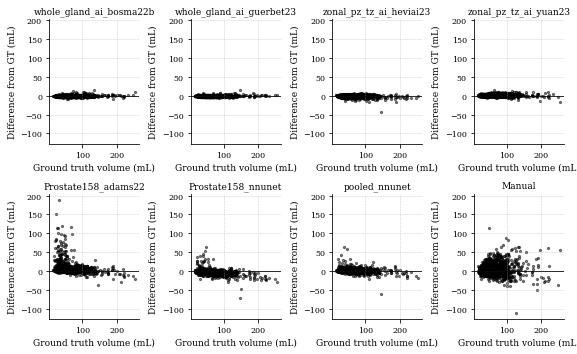

In [7]:
import matplotlib.pyplot as plt

methods = [
    "whole_gland_ai_bosma22b",
    "whole_gland_ai_guerbet23",
    "zonal_pz_tz_ai_heviai23",
    "zonal_pz_tz_ai_yuan23",
    "Prostate158_adams22",
    "Prostate158_nnunet",
    # "PROMISE12_nnunet",
    "pooled_nnunet",
    "prostate_volume",
    # "psa/psad"
]

ncols = 4
nrows = -(-len(methods) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 5), sharex=True, sharey=True)
axes = axes.flatten()

for ax, method in zip(axes, methods):
    diff = volumes[method] - volumes["gt"]
    ax.scatter(volumes["gt"], diff, s=5, alpha=0.5)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title({"prostate_volume": "Manual"}.get(method, method), fontsize=9)
    ax.set_xlabel("Ground truth volume (mL)")
    ax.set_ylabel("Difference from GT (mL)")

for ax in fig.axes:
    ax.tick_params(labelleft=True, labelbottom=True)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

for ax in axes[len(methods):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [8]:
rows = {}
for method in methods:
    diff = volumes[method] - volumes["gt"]
    m, s = diff.mean(), diff.std()
    desc = diff.describe()
    rows[method] = {"mean": m, "loa_lower": m - 1.96*s, "loa_upper": m + 1.96*s,
                    "min": desc["min"], "25%": desc["25%"], "50%": desc["50%"],
                    "75%": desc["75%"], "max": desc["max"]}

pd.DataFrame(rows).T.style.format(precision=1)

,mean,loa_lower,loa_upper,min,25%,50%,75%,max
whole_gland_ai_bosma22b,-0.4,-3.7,2.9,-9.2,-1.2,-0.3,0.2,14.4
whole_gland_ai_guerbet23,-0.5,-3.2,2.3,-6.2,-1.2,-0.4,0.1,16.2
zonal_pz_tz_ai_heviai23,-0.2,-5.5,5.2,-43.3,-1.1,0.3,1.2,6.9
zonal_pz_tz_ai_yuan23,1.7,-3.2,6.6,-17.6,0.2,1.5,3.0,14.4
Prostate158_adams22,7.0,-22.0,36.0,-36.6,1.4,4.0,7.7,188.2
Prostate158_nnunet,-2.4,-15.6,10.8,-73.0,-4.9,-2.2,0.0,64.1
pooled_nnunet,1.9,-8.9,12.7,-62.1,-0.4,1.9,4.1,64.7
prostate_volume,5.1,-25.0,35.3,-112.0,-4.0,3.6,12.4,112.9


In [9]:
import pingouin as pg
from itertools import combinations

n = len(methods)
icc_vals = pd.DataFrame(np.ones((n, n)), index=methods, columns=methods)
icc_ci  = pd.DataFrame("", index=methods, columns=methods)

for m1, m2 in combinations(methods, 2):
    long = pd.concat([
        volumes[["ID", m1]].rename(columns={m1: "volume"}).assign(rater=m1),
        volumes[["ID", m2]].rename(columns={m2: "volume"}).assign(rater=m2),
    ]).dropna(subset=["volume"])

    res = pg.intraclass_corr(data=long, targets="ID", raters="rater", ratings="volume", nan_policy='omit')
    row = res.set_index("Type").loc["ICC(A,1)"]   # two-way mixed, absolute agreement
    icc  = row["ICC"]
    lo, hi = row["CI95"]

    icc_vals.loc[m1, m2] = icc
    icc_vals.loc[m2, m1] = icc
    icc_ci.loc[m1, m2] = f"{icc:.3f} [{lo:.3f}, {hi:.3f}]"
    icc_ci.loc[m2, m1] = icc_ci.loc[m1, m2]

# np.fill_diagonal(icc_ci.values, "1.000")

print("ICC(A,1) — two-way mixed, absolute agreement\n")
icc_vals.style.background_gradient(cmap="RdYlGn", vmin=0.8, vmax=1).format(precision=3)

ICC(A,1) — two-way mixed, absolute agreement



,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,pooled_nnunet,prostate_volume
whole_gland_ai_bosma22b,1.000,0.999,0.993,0.992,0.875,0.972,0.979,0.887
whole_gland_ai_guerbet23,0.999,1.000,0.994,0.992,0.875,0.973,0.980,0.887
zonal_pz_tz_ai_heviai23,0.993,0.994,1.000,0.993,0.882,0.979,0.987,0.894
zonal_pz_tz_ai_yuan23,0.992,0.992,0.993,1.000,0.889,0.969,0.986,0.898
Prostate158_adams22,0.875,0.875,0.882,0.889,1.000,0.863,0.897,0.826
Prostate158_nnunet,0.972,0.973,0.979,0.969,0.863,1.000,0.975,0.866
pooled_nnunet,0.979,0.980,0.987,0.986,0.897,0.975,1.000,0.893
prostate_volume,0.887,0.887,0.894,0.898,0.826,0.866,0.893,1.000


In [10]:
methods = [
    # "gt",
    "whole_gland_ai_bosma22b",
    "whole_gland_ai_guerbet23",
    "zonal_pz_tz_ai_heviai23",
    "zonal_pz_tz_ai_yuan23",
    "Prostate158_adams22",
    "Prostate158_nnunet",
    # "PROMISE12_nnunet",
    "pooled_nnunet",
    "prostate_volume",
    # "psa/psad"
]

psad = volumes.copy()
for method in methods:
    psad[method] = psad["psa"] / volumes[method]
psad["gt"] = psad["psa"] / volumes["gt"]
psad

,ID,t2,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet,pooled_nnunet,...,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa,center,psa/psad
0,10000_1000000,images_nii/10000/10000_1000000_t2w.nii.gz,0.215636,0.216885,0.216132,0.204835,0.196614,0.229059,43.323742,0.198807,...,7.70,NaN,0.140000,MRBx,0+0,0,0,NO,PCNN,NaN
1,10001_1000001,images_nii/10001/10001_1000001_t2w.nii.gz,0.097018,0.098322,0.093766,0.093037,0.088320,0.100001,95.572557,0.096000,...,8.70,0.09,0.085294,NaN,NaN,NaN,0,NO,RUMC,96.666667
2,10002_1000002,images_nii/10002/10002_1000002_t2w.nii.gz,0.061145,0.059540,0.056246,0.056965,0.057379,0.062605,65.831250,0.057991,...,4.20,0.06,0.056757,NaN,NaN,NaN,0,NO,ZGT,70.000000
3,10003_1000003,images_nii/10003/10003_1000003_t2w.nii.gz,0.179518,0.179978,0.174823,0.176012,0.166753,0.187430,76.050000,0.180360,...,13.00,NaN,0.181818,SysBx,0+0,0,0,NO,ZGT,NaN
4,10004_1000004,images_nii/10004/10004_1000004_t2w.nii.gz,0.131630,0.130773,0.130999,0.124170,0.117751,0.134037,64.924092,0.115989,...,8.00,0.10,0.102564,SysBx+MRBx,"0+0,0+0","0,0",0,NO,RUMC,80.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,11471_1001495,images_nii/11471/11471_1001495_t2w.nii.gz,0.241881,0.236331,0.244317,0.244292,0.238529,0.268100,52.391500,0.258075,...,12.50,0.21,0.201613,MRBx,"3+4,N/A,3+3","2,1",2,YES,RUMC,59.523810
1496,11472_1001496,images_nii/11472/11472_1001496_t2w.nii.gz,0.151551,0.150577,0.145386,0.133000,0.074741,0.169446,44.482932,0.128683,...,5.28,0.12,0.120000,SysBx+MRBx,3+4,2,2,YES,RUMC,44.000000
1497,11473_1001497,images_nii/11473/11473_1001497_t2w.nii.gz,0.416589,0.414787,0.403912,0.395441,0.372481,0.409063,80.999676,0.394311,...,29.60,0.34,0.340230,MRBx,0+0,0,0,NO,RUMC,87.058824
1498,11474_1001498,images_nii/11474/11474_1001498_t2w.nii.gz,0.161503,0.159038,0.152705,0.156771,0.143870,0.163904,87.537656,0.148950,...,12.00,NaN,0.144578,MRBx,3+3,1,1,NO,PCNN,NaN


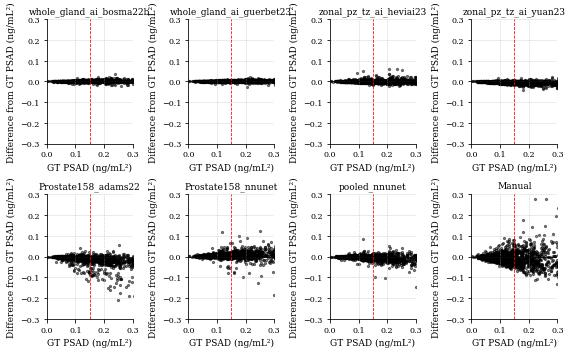

In [11]:
ncols = 4
nrows = -(-len(methods) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 5), sharex=True, sharey=True)
axes = axes.flatten()

for ax, method in zip(axes, methods):
#     # Filter for cases with lesion)
#     mask = psad["lesion_volume"] > 0
#     print(f"{mask.sum()} cases with lesion for method {method}")
#     print(f"Shape of GT PSAD for method {method}: {psad.loc[mask, "gt"].shape}")
#     print(f"Non-NaN values for method {method}: {psad.loc[mask, method].notna().sum()}")

    ax.scatter(psad.loc[:, "gt"], psad.loc[:, method] - psad.loc[:, "gt"], s=5, alpha=0.5)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title({"prostate_volume": "Manual"}.get(method, method), fontsize=9)
    ax.set_xlabel("GT PSAD (ng/mL²)")
    ax.set_ylabel("Difference from GT PSAD (ng/mL²)")

for ax in fig.axes:
    ax.tick_params(labelleft=True, labelbottom=True)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    # ax.set_xscale("log")
    # 1. Force the use of standard decimal representation
    import matplotlib.ticker as ticker
    formatter = ticker.ScalarFormatter()
    formatter.set_powerlimits((-np.inf, np.inf)) 
    # 2. Apply it to the major ticks of your log axis
    ax.xaxis.set_major_formatter(formatter)

    from matplotlib import ticker
    ax.set_xlim([0.0, 0.3])
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.set_ylim([-0.3, +0.3])
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.axvline(0.15, color="r", linewidth=0.8, linestyle="--")

for ax in axes[len(methods):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [12]:
rows = {}
for method in methods:
    diff = psad[method] - psad["gt"]
    print(diff.shape)
    m, s = diff.mean(), diff.std()
    desc = diff.describe()
    rows[{"prostate_volume": "Manual Ellipsoid"}.get(method, method)] = {
        "mean": m, "loa_lower": m - 1.96*s, "loa_upper": m + 1.96*s,
        "min": desc["min"], "25%": desc["25%"], "50%": desc["50%"],
        "75%": desc["75%"], "max": desc["max"]
    }

pd.DataFrame(rows).T.style.format(precision=3)

(1500,)
(1500,)
(1500,)
(1500,)
(1500,)
(1500,)
(1500,)
(1500,)


,mean,loa_lower,loa_upper,min,25%,50%,75%,max
whole_gland_ai_bosma22b,0.002,-0.022,0.026,-0.098,-0.001,0.001,0.004,0.222
whole_gland_ai_guerbet23,0.002,-0.019,0.024,-0.115,-0.000,0.001,0.004,0.202
zonal_pz_tz_ai_heviai23,0.002,-0.043,0.047,-0.246,-0.004,-0.001,0.003,0.476
zonal_pz_tz_ai_yuan23,-0.008,-0.055,0.039,-0.419,-0.009,-0.004,-0.001,0.114
Prostate158_adams22,-0.027,-0.149,0.095,-1.127,-0.027,-0.011,-0.003,0.153
Prostate158_nnunet,0.009,-0.170,0.188,-0.571,-0.000,0.006,0.015,3.115
pooled_nnunet,-0.012,-0.083,0.060,-0.433,-0.014,-0.005,0.001,0.317
Manual Ellipsoid,-0.003,-0.357,0.350,-1.038,-0.031,-0.007,0.012,5.815


In [13]:
rows = {}
for method in methods:
    diff = psad.loc[psad["gt"]<0.3, method] - psad.loc[psad["gt"]<0.3, "gt"]
    print(diff.shape)
    m, s = diff.mean(), diff.std()
    desc = diff.describe()
    rows[{"prostate_volume": "Manual Ellipsoid"}.get(method, method)] = {
        "mean": m, "loa_lower": m - 1.96*s, "loa_upper": m + 1.96*s,
        "min": desc["min"], "25%": desc["25%"], "50%": desc["50%"],
        "75%": desc["75%"], "max": desc["max"]
    }

pd.DataFrame(rows).T.style.format(precision=3)

(1195,)
(1195,)
(1195,)
(1195,)
(1195,)
(1195,)
(1195,)
(1195,)


,mean,loa_lower,loa_upper,min,25%,50%,75%,max
whole_gland_ai_bosma22b,0.001,-0.007,0.010,-0.022,-0.000,0.001,0.003,0.038
whole_gland_ai_guerbet23,0.002,-0.005,0.008,-0.029,-0.000,0.001,0.003,0.022
zonal_pz_tz_ai_heviai23,0.000,-0.014,0.014,-0.022,-0.003,-0.001,0.002,0.062
zonal_pz_tz_ai_yuan23,-0.005,-0.017,0.008,-0.042,-0.007,-0.003,-0.000,0.020
Prostate158_adams22,-0.015,-0.064,0.034,-0.212,-0.018,-0.008,-0.002,0.055
Prostate158_nnunet,0.007,-0.028,0.041,-0.184,0.000,0.005,0.013,0.123
pooled_nnunet,-0.005,-0.031,0.021,-0.148,-0.010,-0.004,0.001,0.086
Manual Ellipsoid,-0.005,-0.092,0.082,-0.133,-0.025,-0.006,0.010,0.930



=== whole_gland_ai_bosma22b ===
Cohen's kappa (linear):    0.952
Cohen's kappa (quadratic): 0.961
              precision    recall  f1-score   support

       <0.10       0.98      0.96      0.97       326
   0.10–0.15       0.96      0.93      0.94       369
   0.15–0.20       0.89      0.95      0.92       240
       ≥0.20       0.98      0.99      0.98       525

    accuracy                           0.96      1460
   macro avg       0.95      0.96      0.95      1460
weighted avg       0.96      0.96      0.96      1460


=== whole_gland_ai_guerbet23 ===
Cohen's kappa (linear):    0.954
Cohen's kappa (quadratic): 0.963
              precision    recall  f1-score   support

       <0.10       0.99      0.95      0.97       326
   0.10–0.15       0.95      0.93      0.94       369
   0.15–0.20       0.90      0.95      0.92       240
       ≥0.20       0.98      0.99      0.99       525

    accuracy                           0.96      1460
   macro avg       0.96      0.96      0

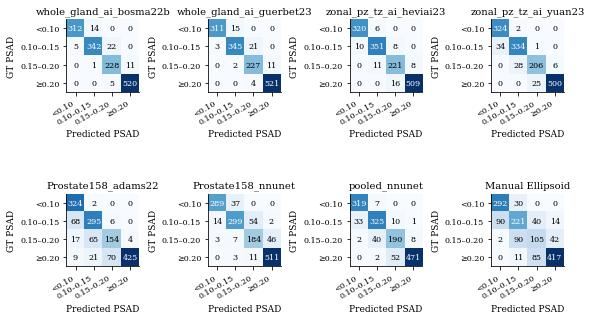

In [14]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

cutoffs = [0.10, 0.15, 0.20]
bins = [0] + cutoffs + [np.inf]
bin_labels = ["<0.10", "0.10–0.15", "0.15–0.20", "≥0.20"]

gt_psad = psad["gt"]
gt_cat = pd.cut(gt_psad, bins=bins, labels=bin_labels, right=False)

ncols = 4
nrows = -(-len(methods) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 5))
axes = axes.flatten()

for ax, method in zip(axes, methods):
    pred_psad = psad[method]
    pred_cat = pd.cut(pred_psad, bins=bins, labels=bin_labels, right=False)

    valid = gt_cat.notna() & pred_cat.notna()
    cm = confusion_matrix(gt_cat[valid], pred_cat[valid], labels=bin_labels)

    kappa = cohen_kappa_score(gt_cat[valid], pred_cat[valid], weights="linear")
    kappa_quad = cohen_kappa_score(gt_cat[valid], pred_cat[valid], weights="quadratic")
    print(f"\n=== {method} ===")
    print(f"Cohen's kappa (linear):    {kappa:.3f}")
    print(f"Cohen's kappa (quadratic): {kappa_quad:.3f}")
    print(classification_report(gt_cat[valid], pred_cat[valid], labels=bin_labels, zero_division=0))

    ax.imshow(cm, cmap="Blues")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(bin_labels, rotation=30, ha="right")
    ax.set_yticklabels(bin_labels)
    ax.set_xlabel("Predicted PSAD")
    ax.set_ylabel("GT PSAD")
    ax.set_title({"prostate_volume": "Manual Ellipsoid"}.get(method, method))

for ax in axes[len(methods):]:
    ax.set_visible(False)

# plt.suptitle("PSAD 4×4 Confusion Matrices (cutoffs: 0.10, 0.15, 0.20)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



=== whole_gland_ai_bosma22b ===
Cohen's kappa (linear):    0.939
Cohen's kappa (quadratic): 0.937
              precision    recall  f1-score   support

       <0.10       0.98      0.96      0.97       326
   0.10–0.15       0.96      0.93      0.94       369
   0.15–0.20       0.89      0.95      0.92       240
   0.20–0.30       0.96      0.98      0.97       260

    accuracy                           0.95      1195
   macro avg       0.95      0.95      0.95      1195
weighted avg       0.95      0.95      0.95      1195


=== whole_gland_ai_guerbet23 ===
Cohen's kappa (linear):    0.942
Cohen's kappa (quadratic): 0.940
              precision    recall  f1-score   support

       <0.10       0.99      0.95      0.97       326
   0.10–0.15       0.95      0.93      0.94       369
   0.15–0.20       0.90      0.95      0.92       240
   0.20–0.30       0.96      0.98      0.97       260

    accuracy                           0.95      1195
   macro avg       0.95      0.95      0

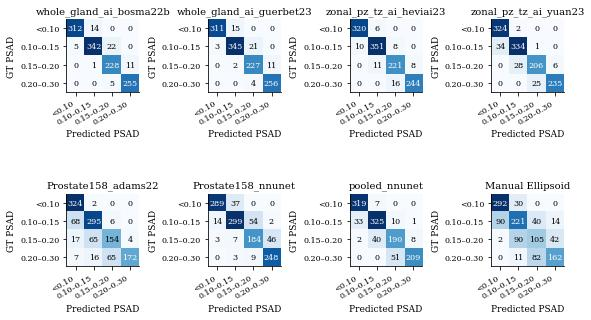

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

cutoffs = [0.10, 0.15, 0.20]
bins = [0] + cutoffs + [np.inf]
bin_labels = ["<0.10", "0.10–0.15", "0.15–0.20", "0.20–0.30"]

gt_psad = psad["gt"]
gt_cat = pd.cut(gt_psad, bins=bins, labels=bin_labels, right=False)

ncols = 4
nrows = -(-len(methods) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 5))
axes = axes.flatten()

psad_mask = psad["gt"] < 0.3  # restrict to clinically relevant range

for ax, method in zip(axes, methods):
    pred_psad = psad[method]
    pred_cat = pd.cut(pred_psad, bins=bins, labels=bin_labels, right=False)

    valid = gt_cat.notna() & pred_cat.notna() & psad_mask
    cm = confusion_matrix(gt_cat[valid], pred_cat[valid], labels=bin_labels)

    kappa = cohen_kappa_score(gt_cat[valid], pred_cat[valid], weights="linear")
    kappa_quad = cohen_kappa_score(gt_cat[valid], pred_cat[valid], weights="quadratic")
    print(f"\n=== {method} ===")
    print(f"Cohen's kappa (linear):    {kappa:.3f}")
    print(f"Cohen's kappa (quadratic): {kappa_quad:.3f}")
    print(classification_report(gt_cat[valid], pred_cat[valid], labels=bin_labels, zero_division=0))

    ax.imshow(cm, cmap="Blues")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(bin_labels, rotation=30, ha="right")
    ax.set_yticklabels(bin_labels)
    ax.set_xlabel("Predicted PSAD")
    ax.set_ylabel("GT PSAD")
    ax.set_title({"prostate_volume": "Manual Ellipsoid"}.get(method, method))

for ax in axes[len(methods):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


whole_gland_ai_bosma22b: AUC = 0.737, PSAD cutoff at threshold=0.150, FPR=0.444, TPR=0.774
whole_gland_ai_guerbet23: AUC = 0.738, PSAD cutoff at threshold=0.150, FPR=0.441, TPR=0.774
zonal_pz_tz_ai_heviai23: AUC = 0.741, PSAD cutoff at threshold=0.150, FPR=0.425, TPR=0.767
zonal_pz_tz_ai_yuan23: AUC = 0.738, PSAD cutoff at threshold=0.151, FPR=0.407, TPR=0.748
Prostate158_adams22: AUC = 0.729, PSAD cutoff at threshold=0.150, FPR=0.346, TPR=0.707
Prostate158_nnunet: AUC = 0.738, PSAD cutoff at threshold=0.151, FPR=0.455, TPR=0.791
pooled_nnunet: AUC = 0.732, PSAD cutoff at threshold=0.150, FPR=0.401, TPR=0.750
prostate_volume: AUC = 0.723, PSAD cutoff at threshold=0.150, FPR=0.396, TPR=0.723


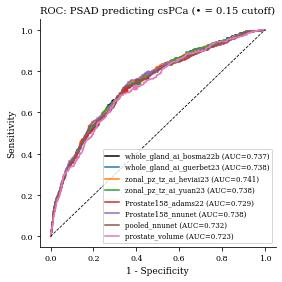

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true = volumes["case_csPCa"].map({"YES": 1, "NO": 0}).dropna()
idx = y_true.index

fig, ax = plt.subplots(figsize=(4, 4))
for method in methods:
    score = (volumes.loc[idx, "psa"] / volumes.loc[idx, method]).dropna()
    valid = y_true.loc[score.index]
    fpr, tpr, thresholds = roc_curve(valid, score)
    auc = roc_auc_score(valid, score)
    (line,) = ax.plot(fpr, tpr, label=f"{method} (AUC={auc:.3f})")
    # Mark the point closest to PSAD=0.15 cutoff
    cut_idx = np.argmin(np.abs(thresholds - 0.15))
    print(f"{method}: AUC = {auc:.3f}, PSAD cutoff at threshold={thresholds[cut_idx]:.3f}, FPR={fpr[cut_idx]:.3f}, TPR={tpr[cut_idx]:.3f}")
    ax.plot(fpr[cut_idx], tpr[cut_idx], "o", color=line.get_color(), markersize=5)

ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("1 - Specificity")
ax.set_ylabel("Sensitivity")
ax.set_title("ROC: PSAD predicting csPCa (• = 0.15 cutoff)")
ax.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()


whole_gland_ai_bosma22b: AUC = 0.677, PSAD cutoff at threshold=0.150, FPR=0.378, TPR=0.641
whole_gland_ai_guerbet23: AUC = 0.678, PSAD cutoff at threshold=0.150, FPR=0.374, TPR=0.641
zonal_pz_tz_ai_heviai23: AUC = 0.684, PSAD cutoff at threshold=0.150, FPR=0.357, TPR=0.630
zonal_pz_tz_ai_yuan23: AUC = 0.679, PSAD cutoff at threshold=0.151, FPR=0.337, TPR=0.599
Prostate158_adams22: AUC = 0.661, PSAD cutoff at threshold=0.150, FPR=0.275, TPR=0.534
Prostate158_nnunet: AUC = 0.677, PSAD cutoff at threshold=0.151, FPR=0.390, TPR=0.668
pooled_nnunet: AUC = 0.669, PSAD cutoff at threshold=0.150, FPR=0.331, TPR=0.607
prostate_volume: AUC = 0.657, PSAD cutoff at threshold=0.150, FPR=0.324, TPR=0.564


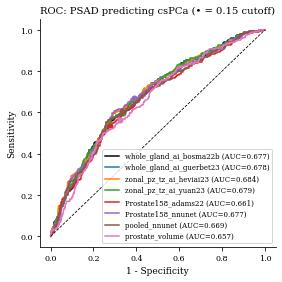

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true = volumes.loc[volumes["psa"] / volumes["gt"] < 0.3, "case_csPCa"].map({"YES": 1, "NO": 0}).dropna()
idx = y_true.index

fig, ax = plt.subplots(figsize=(4, 4))
for method in methods:
    score = (volumes.loc[idx, "psa"] / volumes.loc[idx, method]).dropna()
    valid = y_true.loc[score.index]
    fpr, tpr, thresholds = roc_curve(valid, score)
    auc = roc_auc_score(valid, score)
    (line,) = ax.plot(fpr, tpr, label=f"{method} (AUC={auc:.3f})")
    # Mark the point closest to PSAD=0.15 cutoff
    cut_idx = np.argmin(np.abs(thresholds - 0.15))
    print(f"{method}: AUC = {auc:.3f}, PSAD cutoff at threshold={thresholds[cut_idx]:.3f}, FPR={fpr[cut_idx]:.3f}, TPR={tpr[cut_idx]:.3f}")
    ax.plot(fpr[cut_idx], tpr[cut_idx], "o", color=line.get_color(), markersize=5)

ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("1 - Specificity")
ax.set_ylabel("Sensitivity")
ax.set_title("ROC: PSAD predicting csPCa (• = 0.15 cutoff)")
ax.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()


In [18]:
from concurrent.futures import ProcessPoolExecutor
import os
from itertools import combinations

SEG_COLS = [
    "whole_gland_ai_bosma22b",
    "whole_gland_ai_guerbet23",
    "zonal_pz_tz_ai_heviai23", # lots of missing slices that require resampling
    "zonal_pz_tz_ai_yuan23",
    "Prostate158_adams22",
    "Prostate158_nnunet",
    # "PROMISE12_nnunet",
    "pooled_nnunet",
]

def _pairwise_dsc_case(row):
    import SimpleITK as sitk
    import numpy as np

    ref_img = sitk.ReadImage(str(row[SEG_COLS[0]]), sitk.sitkUInt8)
    masks = {SEG_COLS[0]: sitk.GetArrayFromImage(ref_img).ravel() > 0}
    for col in SEG_COLS[1:]:
        img = sitk.ReadImage(str(row[col]), sitk.sitkUInt8)
        needs_resample = (
            img.GetSize() != ref_img.GetSize()
            or not np.allclose(img.GetSpacing(), ref_img.GetSpacing(), rtol=1e-4)
            or not np.allclose(img.GetOrigin(), ref_img.GetOrigin(), rtol=1e-4)
        )
        if needs_resample:
            print(f"ID: {row['ID']}, {SEG_COLS[0]} vs {col} needs resampling")
            if not img.GetSize() == ref_img.GetSize():
                print(f"  Size mismatch: {img.GetSize()} vs {ref_img.GetSize()}")
            if not np.allclose(img.GetSpacing(), ref_img.GetSpacing(), rtol=1e-4):
                print(f"  Spacing mismatch: {img.GetSpacing()} vs {ref_img.GetSpacing()}")
            if not np.allclose(img.GetOrigin(), ref_img.GetOrigin(), rtol=1e-4):
                print(f"  Origin mismatch: {img.GetOrigin()} vs {ref_img.GetOrigin()}")
            img = sitk.Resample(img, ref_img, sitk.Transform(),
                                sitk.sitkNearestNeighbor, 0, sitk.sitkUInt8)
        masks[col] = sitk.GetArrayFromImage(img).ravel() > 0

    results = {"ID": row["ID"]}
    for m1, m2 in combinations(SEG_COLS, 2):
        a, b = masks[m1], masks[m2]
        denom = int(a.sum()) + int(b.sum())
        results[f"{m1}||{m2}"] = (
            2 * int((a & b).sum()) / denom if denom > 0 else float("nan")
        )
    return results

rows = picai_cases.to_dict("records")
with ProcessPoolExecutor(max_workers=os.cpu_count() - 1) as pool:
    dsc_records = list(tqdm(pool.map(_pairwise_dsc_case, rows), total=len(rows)))

dsc_df = pd.DataFrame(dsc_records)

# Build NÃN mean DSC matrix
dsc_matrix = pd.DataFrame(np.ones((len(SEG_COLS), len(SEG_COLS))),
                           index=SEG_COLS, columns=SEG_COLS)
for m1, m2 in combinations(SEG_COLS, 2):
    val = dsc_df[f"{m1}||{m2}"].mean()
    dsc_matrix.loc[m1, m2] = val
    dsc_matrix.loc[m2, m1] = val

print("Mean pairwise DSC across 1500 cases\n")
dsc_matrix.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1).format(precision=3)


ID: 10018_1000018, whole_gland_ai_bosma22b vs zonal_pz_tz_ai_heviai23 needs resamplingID: 10027_1000027, whole_gland_ai_bosma22b vs zonal_pz_tz_ai_heviai23 needs resampling

  Size mismatch: (335, 335, 23) vs (384, 384, 25)  Size mismatch: (307, 307, 23) vs (320, 320, 23)

  Origin mismatch: (-94.31295776367188, -93.90947723388672, 0.07289589196443558) vs (-108.06295776367188, -108.03453063964844, 1.4128090143203735)

  0%|          | 0/1500 [00:00<?, ?it/s]


  Origin mismatch: (-91.6055679321289, -84.25773620605469, -16.217361450195312) vs (-95.3510513305664, -87.7656021118164, -14.878998756408691)
ID: 10000_1000000, whole_gland_ai_bosma22b vs zonal_pz_tz_ai_heviai23 needs resamplingID: 10015_1000015, whole_gland_ai_bosma22b vs zonal_pz_tz_ai_heviai23 needs resampling

  Size mismatch: (561, 561, 27) vs (1024, 1024, 27)  Size mismatch: (640, 640, 25) vs (640, 640, 31)  Origin mismatch: (-104.52371978759766, -78.08634948730469, -13.971171379089355) vs (-180.63995361328125, -156.5455780029297, 9.528315544128418)

  Origin mismatch: (-109.22891235351562, -72.7301254272461, -75.18688201904297) vs (-109.22891235351562, -76.6142578125, -84.2931137084961)

ID: 10009_1000009, whole_gland_ai_bosma22b vs zonal_pz_tz_ai_heviai23 needs resamplingID: 10022_1000022, whole_gland_ai_bosma22b vs zonal_pz_tz_ai_heviai23 needs resampling

  Size mismatch: (561, 561, 27) vs (1024, 1024, 27)  Size mismatch: (561, 561, 27) vs (1024, 1024, 27)

  Origin mismatc

,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,pooled_nnunet
whole_gland_ai_bosma22b,1.000,0.980,0.931,0.941,0.848,0.876,0.912
whole_gland_ai_guerbet23,0.980,1.000,0.937,0.944,0.853,0.882,0.918
zonal_pz_tz_ai_heviai23,0.931,0.937,1.000,0.946,0.857,0.887,0.927
zonal_pz_tz_ai_yuan23,0.941,0.944,0.946,1.000,0.855,0.881,0.923
Prostate158_adams22,0.848,0.853,0.857,0.855,1.000,0.841,0.857
Prostate158_nnunet,0.876,0.882,0.887,0.881,0.841,1.000,0.892
pooled_nnunet,0.912,0.918,0.927,0.923,0.857,0.892,1.000


In [19]:
# Find human errors: cases where the difference between the ground truth and the volume is large. We can look at both absolute and relative differences.
df = volumes[["ID", 'gt', "prostate_volume", 'psa/psad', 'psa', 'psad', 'whole_gland_ai_bosma22b', 'whole_gland_ai_guerbet23',
       'zonal_pz_tz_ai_heviai23', 'zonal_pz_tz_ai_yuan23',
       'Prostate158_adams22', 'Prostate158_nnunet', 'PROMISE12_nnunet']].dropna()
# df[df.eval("abs(prostate_volume - gt)").argsort()]
large_abs_diff = df.iloc[df.eval("abs(prostate_volume - gt)").argsort()[::-1]]
large_abs_diff.head()

,ID,gt,prostate_volume,psa/psad,psa,psad,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet
1315,11292_1001315,124.978500,13.0,112.500000,13.50,0.12,123.588750,124.506750,125.450250,136.308750,128.612250,117.651000,124.378500
1272,11249_1001272,102.758058,184.0,44.000000,0.44,0.01,103.145400,102.370716,100.581264,110.214108,110.959977,96.505992,86.750676
888,10872_1000888,83.533875,148.0,144.545455,15.90,0.11,83.135250,83.932500,86.472750,82.966500,92.268000,87.019500,93.318000
183,10180_1000183,133.534125,196.0,187.500000,15.00,0.08,147.951000,140.184000,125.139750,126.884250,132.422250,123.233250,121.657500
643,10629_1000643,122.110578,183.0,183.333333,11.00,0.06,119.997612,117.756504,124.223544,125.828964,130.189020,124.345692,120.756096


In [20]:
large_rel_diff = df.iloc[df.eval("abs(log(prostate_volume) - log(gt))").argsort()[::-1]]
large_rel_diff.head()

,ID,gt,prostate_volume,psa/psad,psa,psad,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet
1315,11292_1001315,124.978500,13.0,112.500000,13.50,0.12,123.588750,124.506750,125.450250,136.308750,128.612250,117.651000,124.378500
783,10767_1000783,44.549028,90.0,90.000000,9.90,0.11,42.794244,43.011972,46.086084,46.571760,52.385616,45.178560,51.858144
441,10433_1000441,25.639416,13.0,13.142857,4.60,0.35,25.431732,25.306344,25.847100,33.447492,27.148284,17.959968,28.625724
1174,11151_1001174,52.299486,101.0,100.000000,12.00,0.12,51.684962,51.949225,52.649748,56.417767,64.777347,53.412920,77.211353
1436,11412_1001436,16.007544,30.0,19.666667,0.59,0.03,15.142140,14.936724,17.596764,16.872948,18.802692,17.659944,20.949840
